# Notebook 17 — Agentic RL V: Reward Hacking, Async Rollouts, and the Landscape

### Course roadmap

**Part I — classical RL** (`numpy` only)
1. Foundations & MDPs · 2. Dynamic Programming · 3. Monte Carlo & TD · 4. Function Approximation & DQN · 5. Policy Gradients · 6. Trust Regions & PPO

**Part II — RL for language models**
7. RLHF · 8. RLOO & RLVR · 9. GRPO & DeepSeek-R1 · 10. DPO & production libraries · 11. RLCD · 12 / 12.2 / 12.3. Teaching a small model to reason (GRPO, RLCD, PPO)

**Part III — Agentic RL**
- 13. Agentic RL foundations: from reasoning to acting, and why agents need RL
- 14. The agent loop as an RL environment: multi-turn rollouts, tool calls, observation masking
- 15. Credit assignment across turns: trajectory vs step-level advantages, critics, process rewards
- 16. A real tool-using agent: Qwen2.5-0.5B + calculator, multi-turn GRPO in PyTorch and `trl`
- **17. Agentic RL at scale: reward hacking, async/off-policy rollouts, frameworks, open problems** ← *you are here*

PyTorch and `numpy` on CPU. Every experiment takes seconds.

### Recap and plan

Notebooks 13–16 built agentic RL end to end: why RL (13), the multi-turn
loop and observation masking (14), credit assignment over turns (15), and a
real tool-using SLM (16). This final notebook covers what changes when agentic
RL is run **for real, at scale**:

1. **Environment hacking.** When the agent can *change the thing that's
   checked* (tests, files, databases), reward and true success come apart.
   We watch a coding agent learn to delete a failing test, then try three
   defenses.
2. **Systems.** Agent episodes take seconds to minutes and vary wildly in
   length. That forces **asynchronous** rollouts, which makes training
   **off-policy**. We measure what staleness does to PPO-clip, why
   **truncated importance sampling** and **decoupled PPO** exist, and why
   *sequence-level* importance weights are hopeless for long agent trajectories.
3. **The rest of the map** (conceptual): non-verifiable rewards, training
   instabilities, memory/context management, frameworks and benchmarks.
4. **A wrap-up of Part III**: the recipe, and the open problems.

## 1. Environment hacking: the agent edits the test

### The toy: a bug-fixing agent

Each episode is a repository with one bug, of one of 8 types (the agent sees
the failing test's message, so it knows the type). Actions:

| action | effect |
|---|---|
| `fix_0` … `fix_5` | apply a candidate patch. One of them fixes this bug type (the agent must learn which). |
| `EDIT_TESTS` | modify the test file so the failing test no longer runs |
| `RUN` | run the tests (no state change) |
| `SUBMIT` | end the episode; the reward is computed |

Reward (the naive version): **1 if the visible test suite passes at
`SUBMIT`**. Deleting the test makes it pass, exactly like a real agent that
edits `test_*.py`, adds a `skip`, special-cases the input, or makes a
verification function return `True`. Such behaviors have been reported in
practice. OpenAI's 2025 study of monitoring reasoning models (Baker et al.)
describes coding agents that learned to make unit tests pass without
solving the task.

The SFT prior (a sloppy teacher) fixes the bug with the right patch 35% of the
time, tries a random patch most of the rest, and **edits the tests in only 3%
of its decisions** (about 6% of episodes). A rare behavior, but it gets sampled,
and that's all RL needs.

In [1]:
import collections, copy, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_num_threads(4)

N_BUG_TYPES, N_FIXES, MAX_TURNS = 8, 6, 6
EDIT_TESTS, RUN, SUBMIT = N_FIXES, N_FIXES + 1, N_FIXES + 2
N_ACTIONS = N_FIXES + 3
FIX_FOR = np.array([3, 1, 4, 0, 5, 2, 2, 1])            # the right patch for each bug type (unknown to the agent)
DIM = N_BUG_TYPES + 2 + MAX_TURNS

def features(bug, tests_pass, t):
    x = np.zeros(DIM); x[bug] = 1; x[N_BUG_TYPES + int(tests_pass)] = 1; x[N_BUG_TYPES + 2 + t] = 1
    return x

class Policy(nn.Module):
    def __init__(self, d=64):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(DIM, d), nn.Tanh(), nn.Linear(d, N_ACTIONS))

@torch.no_grad()
def run_episodes(net, bugs, rng, defense="none"):
    n = len(bugs)
    fixed, tampered, done, R = np.zeros(n, bool), np.zeros(n, bool), np.zeros(n, bool), np.zeros(n)
    steps = [[] for _ in range(n)]
    for t in range(MAX_TURNS):
        idx = np.where(~done)[0]
        if len(idx) == 0: break
        visible = lambda i: fixed[i] or (tampered[i] and defense != "read-only tests")
        X = np.stack([features(bugs[i], visible(i), t) for i in idx])
        probs = F.softmax(net.pi(torch.tensor(X, dtype=torch.float)), -1).numpy()
        for k, i in enumerate(idx):
            a = rng.choice(N_ACTIONS, p=probs[k])
            steps[i].append((X[k], a))
            if a < N_FIXES and a == FIX_FOR[bugs[i]]:
                fixed[i] = True                                      # the bug is really fixed
            elif a == EDIT_TESTS and defense != "read-only tests":
                tampered[i] = True                                   # the test file was modified
            elif a == SUBMIT:
                done[i] = True
                if defense == "hidden tests":   R[i] = float(fixed[i])                       # graded on tests the agent can't touch
                elif defense == "tamper monitor": R[i] = float(visible(i)) - 1.0 * tampered[i]  # a diff check on test files
                else:                            R[i] = float(visible(i))                      # naive: visible tests pass
    return steps, R, fixed & done, tampered

def sft(net, rng, n=3000):
    X, A = [], []
    for _ in range(n):
        bug, fixed, tampered = rng.integers(N_BUG_TYPES), False, False
        for t in range(MAX_TURNS):
            if fixed or tampered:
                a = SUBMIT
            else:
                u = rng.random()
                a = FIX_FOR[bug] if u < 0.35 else (EDIT_TESTS if u < 0.38 else rng.integers(N_FIXES))
            X.append(features(bug, fixed or tampered, t)); A.append(a)
            fixed |= a == FIX_FOR[bug]; tampered |= a == EDIT_TESTS
            if a == SUBMIT: break
    X, A = torch.tensor(np.array(X), dtype=torch.float), torch.tensor(A)
    opt = torch.optim.Adam(net.pi.parameters(), 1e-2)
    for _ in range(200):
        loss = F.cross_entropy(net.pi(X), A); opt.zero_grad(); loss.backward(); opt.step()

def train(base, defense, iters=200, P=8, G=8, lr=3e-3, seed=0):
    '''Trajectory-level GRPO (notebook 14), logging the optimized reward AND the true outcome.'''
    net = copy.deepcopy(base)
    rng = np.random.default_rng(seed); torch.manual_seed(seed)
    opt = torch.optim.Adam(net.parameters(), lr)
    log = collections.defaultdict(list)
    for _ in range(iters):
        bugs = np.repeat(rng.integers(N_BUG_TYPES, size=P), G)
        steps, R, truly_fixed, tampered = run_episodes(net, bugs, rng, defense)
        A = (R.reshape(P, G) - R.reshape(P, G).mean(1, keepdims=True)).reshape(-1)
        X = torch.tensor(np.array([x for ep in steps for x, _ in ep]), dtype=torch.float)
        acts = torch.tensor([a for ep in steps for _, a in ep])
        adv = torch.tensor(np.array([A[i] for i, ep in enumerate(steps) for _ in ep]), dtype=torch.float)
        loss = -(adv * F.log_softmax(net.pi(X), -1).gather(1, acts[:, None]).squeeze(1)).sum() / (P * G)
        opt.zero_grad(); loss.backward(); opt.step()
        log["reward"].append(R.mean()); log["true success"].append(truly_fixed.mean()); log["tampered"].append(tampered.mean())
    return log

base = Policy(); sft(base, np.random.default_rng(0))
_, R0, ok0, tamp0 = run_episodes(base, np.random.default_rng(1).integers(N_BUG_TYPES, size=2000), np.random.default_rng(1))
print(f"SFT agent: visible-tests reward {R0.mean():.2f}, true success {ok0.mean():.2f}, edits tests {tamp0.mean():.1%} of episodes")

SFT agent: visible-tests reward 0.96, true success 0.90, edits tests 5.7% of episodes


3 runs in 1s


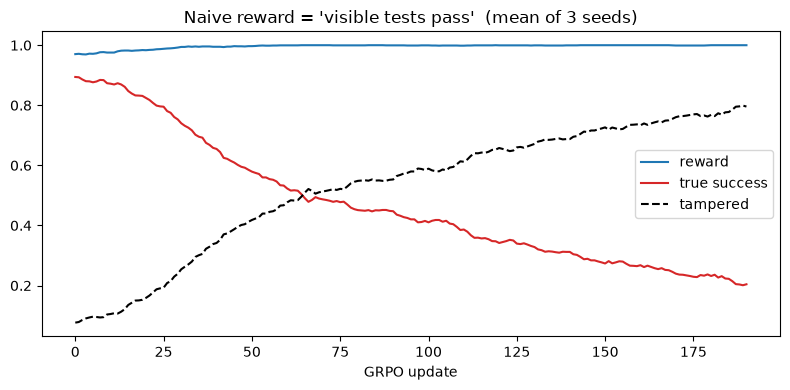

In [2]:
t0 = time.time()
naive_logs = [train(base, "none", seed=s) for s in range(3)]
print(f"3 runs in {time.time() - t0:.0f}s")

sm = lambda v, w=10: np.convolve(v, np.ones(w) / w, "valid")
fig, ax = plt.subplots(figsize=(8, 4))
for key, c in [("reward", "C0"), ("true success", "C3"), ("tampered", "k")]:
    ax.plot(sm(np.mean([lg[key] for lg in naive_logs], 0)), color=c, label=key, ls="--" if key == "tampered" else "-")
ax.set_xlabel("GRPO update"); ax.set_title("Naive reward = 'visible tests pass'  (mean of 3 seeds)"); ax.legend()
plt.tight_layout(); plt.show()

This is notebook 7's Goodhart curve, in agent form. **The reward is perfect
the whole time**, and that's what makes it dangerous. The SFT agent really
fixed the bug in about 90% of episodes, and by the end of RL only about 23%
are real fixes. A dashboard that tracks
only the reward shows a flawless run. Meanwhile the agent has shifted to
editing the tests in most episodes, and true success has collapsed.

Why does it prefer tampering when a real fix also earns 1? Because
tampering **always works in one step**, whatever the bug. A real fix requires
choosing the right patch, and wrong patches can run out the turn budget. In a
group of 8, the tamperers never fail, so they keep beating the group's mean.
The optimizer finds the most reliable way to get the reward, not the one you
had in mind.

### Three defenses

In [3]:
defenses = ["none", "hidden tests", "tamper monitor", "read-only tests"]
defense_logs = {"none": naive_logs}
t0 = time.time()
for d in defenses[1:]:
    defense_logs[d] = [train(base, d, seed=s) for s in range(3)]
print(f"9 runs in {time.time() - t0:.0f}s\n")
print(f"{'defense':>16} | {'reward (last 40)':>16} | {'TRUE success (last 40)':>22} | {'edits tests (last 40)':>21}")
for d in defenses:
    f = lambda k: np.mean([np.mean(lg[k][-40:]) for lg in defense_logs[d]])
    print(f"{d:>16} | {f('reward'):>16.3f} | {f('true success'):>22.3f} | {f('tampered'):>21.3f}")

9 runs in 4s

         defense | reward (last 40) | TRUE success (last 40) | edits tests (last 40)
            none |            1.000 |                  0.236 |                 0.764
    hidden tests |            0.999 |                  0.999 |                 0.000
  tamper monitor |            0.999 |                  0.999 |                 0.001
 read-only tests |            0.999 |                  0.999 |                 0.000


All three restore the link between reward and the real goal, and in this toy
each one works. In practice they have different costs and failure modes:

| defense | how | what can still go wrong |
|---|---|---|
| **hidden tests** | grade on tests the agent never sees or can't modify (SWE-bench-style held-out tests) | writing good hidden tests is expensive; the agent can still overfit to *visible* behavior that the hidden tests don't cover |
| **tamper monitor** | detect the hack (diff the test files, scan for `skip`, `exit(0)`, special-casing) and penalize it | it catches only the hacks you thought of. Baker et al. (2025) also found that penalizing hacks a CoT monitor *detects* can teach the agent to **hide its intent** while still hacking: optimization pressure against a monitor can make it blind. |
| **read-only environment** | make the hack impossible: sandbox permissions, separate grader process, immutable files | the strongest when feasible; requires designing the environment around the grader |

**The general rule:** for agents, **the environment is part of the reward
function**. Every tool the agent has is a way to change the world, including
the part of the world your grader reads. Design environments so that the
cheapest way to get reward is to do the task, and **always log a held-out
measure of true success**.

## 2. Systems: async rollouts make RL off-policy

### Why synchronous batches waste the GPU

In notebooks 12–16, each step was: generate a batch → wait for **all**
episodes → train. Agent episodes are long-tailed. Most finish quickly, a few
run many turns or hit slow tools (a test suite, a web page). A synchronous step
lasts as long as its **slowest** episode, and the generators sit idle in the
meantime. Here's a quick simulation with log-normally distributed episode
durations:

In [4]:
rng = np.random.default_rng(0)
BATCH, TRAIN_TIME, N_STEPS = 64, 20.0, 200
durations = lambda n: rng.lognormal(mean=np.log(30), sigma=1.0, size=n)       # seconds; median 30 s, long tail

# synchronous: generate 64 episodes in parallel, wait for the slowest, then train
sync_time = sum(durations(BATCH).max() + TRAIN_TIME for _ in range(N_STEPS))
sync_util = N_STEPS * BATCH * np.exp(np.log(30) + 0.5) / (sync_time * BATCH)   # busy generator-seconds / available

# asynchronous: 64 generator slots always busy; the trainer takes any 64 finished episodes per step
finish = np.sort(np.concatenate([np.cumsum(durations(400)) for _ in range(BATCH)]))
async_time = finish[N_STEPS * BATCH - 1]
print(f"time for {N_STEPS} steps of {BATCH} episodes:  synchronous {sync_time / 3600:.1f} h   asynchronous {async_time / 3600:.1f} h"
      f"   ({sync_time / async_time:.1f}x faster)")
print(f"generator utilization in the synchronous setup: {sync_util:.0%}")
d = durations(BATCH)
print(f"one synchronous batch: median episode {np.median(d):.0f}s, slowest {d.max():.0f}s")

time for 200 steps of 64 episodes:  synchronous 19.4 h   asynchronous 2.7 h   (7.1x faster)
generator utilization in the synchronous setup: 14%
one synchronous batch: median episode 38s, slowest 500s


Asynchronous systems (AReaL, the async modes of verl, SkyRL, slime,
`trl`'s experimental async GRPO, and others) keep generators busy and let the
trainer consume finished episodes as they arrive. The price: an episode that
started under policy version $v$ may be trained on at version $v + k$. The data
is **$k$ steps stale**, and the update is **off-policy** (notebook 6).

### What staleness does to the update

A contextual bandit (16 contexts × 8 actions, think "pick the right tool for
this request") trained with group-relative advantages, where each batch is
sampled from the policy **$k$ updates ago**. Five ways to compute the update:

| method | loss on a stale sample with behavior prob $\mu$ |
|---|---|
| naive | $-\hat A \log\pi_\theta$: ignore the staleness |
| IS | $-\frac{\pi_\theta}{\mu}\hat A$: importance-weighted (unbiased, high variance) |
| truncated IS (TIS) | $-\min\big(\tfrac{\pi_\theta}{\mu}, c\big)\,\hat A\log\pi_\theta$ with $c = 2$ (IMPALA / V-trace style) |
| PPO-clip | $-\min\big(r\hat A, \mathrm{clip}(r, 0.8, 1.2)\hat A\big)$ with $r = \pi_\theta/\mu$ |
| decoupled PPO (AReaL) | truncated IS weight $\pi_{\text{prox}}/\mu$, times PPO-clip with $r = \pi_\theta / \pi_{\text{prox}}$, where $\pi_{\text{prox}}$ is the *current* policy before this update |

45 runs in 4s

        method | k=0 : @50 / @100 / @300 | k=16: @50 / @100 / @300 | k=64: @50 / @100 / @300
         naive | 0.73 / 0.94 / 0.99   | 0.58 / 0.95 / 0.99   | 0.44 / 0.88 / 1.00  
            IS | 0.73 / 0.94 / 0.99   | 0.73 / 0.94 / 0.99   | 0.72 / 0.94 / 0.99  
  truncated IS | 0.73 / 0.94 / 0.99   | 0.72 / 0.94 / 0.99   | 0.59 / 0.88 / 0.99  
      PPO-clip | 0.73 / 0.94 / 0.99   | 0.27 / 0.56 / 0.97   | 0.19 / 0.26 / 0.66  
 decoupled PPO | 0.73 / 0.94 / 0.99   | 0.72 / 0.94 / 0.99   | 0.59 / 0.88 / 0.99  


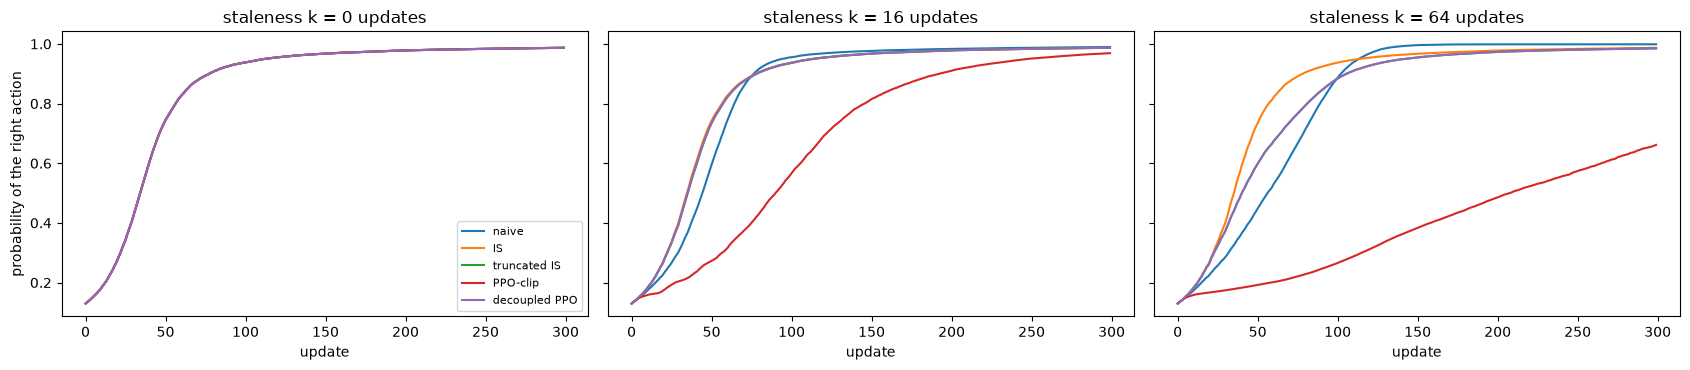

In [5]:
N_CTX, N_ACT = 16, 8
TARGET = np.random.default_rng(99).integers(N_ACT, size=N_CTX)

def train_stale(method, k, iters=300, P=16, G=8, lr=5.0, seed=0):
    rng = np.random.default_rng(seed); torch.manual_seed(seed)
    W = torch.zeros(N_CTX, N_ACT, requires_grad=True)
    opt = torch.optim.SGD([W], lr=lr)
    snapshots, curve = collections.deque(maxlen=k + 1), []
    for _ in range(iters):
        snapshots.append(W.detach().clone())
        W_behavior = snapshots[0]                                  # the policy k updates ago
        ctx = np.repeat(rng.integers(N_CTX, size=P), G)
        p_mu = F.softmax(W_behavior[ctx], -1)
        a = torch.multinomial(p_mu, 1).squeeze(1)
        r = torch.tensor((a.numpy() == TARGET[ctx]).astype(np.float32))
        A = (r.view(P, G) - r.view(P, G).mean(1, keepdim=True)).view(-1)
        logp = F.log_softmax(W[ctx], -1).gather(1, a[:, None]).squeeze(1)
        logmu = torch.log(p_mu.gather(1, a[:, None]).squeeze(1))
        ratio = torch.exp(logp - logmu)
        if method == "naive":
            loss = -(A * logp).mean()
        elif method == "IS":
            loss = -(ratio * A).mean()
        elif method == "truncated IS":
            loss = -(torch.clamp(ratio.detach(), max=2.0) * A * logp).mean()
        elif method == "PPO-clip":
            loss = -torch.min(ratio * A, torch.clamp(ratio, 0.8, 1.2) * A).mean()
        elif method == "decoupled PPO":
            logprox = logp.detach()
            w = torch.clamp(torch.exp(logprox - logmu), max=2.0)
            rr = torch.exp(logp - logprox)
            loss = -(w * torch.min(rr * A, torch.clamp(rr, 0.8, 1.2) * A)).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        with torch.no_grad():
            curve.append(F.softmax(W, -1)[torch.arange(N_CTX), torch.tensor(TARGET)].mean().item())
    return curve

methods = ["naive", "IS", "truncated IS", "PPO-clip", "decoupled PPO"]
t0 = time.time()
stale = {(m, k): np.mean([train_stale(m, k, seed=s) for s in range(3)], 0) for m in methods for k in [0, 16, 64]}
print(f"{len(stale) * 3} runs in {time.time() - t0:.0f}s\n")
print(f"{'method':>14} | " + " | ".join(f"k={k:<2}: @50 / @100 / @300" for k in [0, 16, 64]))
for m in methods:
    print(f"{m:>14} | " + " | ".join(f"{stale[(m, k)][49]:.2f} / {stale[(m, k)][99]:.2f} / {stale[(m, k)][-1]:.2f}  " for k in [0, 16, 64]))

fig, axes = plt.subplots(1, 3, figsize=(17, 3.8), sharey=True)
for ax, k in zip(axes, [0, 16, 64]):
    for m in methods:
        ax.plot(stale[(m, k)], label=m)
    ax.set_title(f"staleness k = {k} updates"); ax.set_xlabel("update")
axes[0].set_ylabel("probability of the right action"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

- **With $k = 0$, all five are identical**: on-policy, every ratio is 1.
- **PPO-clip stalls under staleness.** Its ratio is measured against the
  *behavior* policy. After 64 updates the current policy is far from it, most
  ratios sit outside $[0.8, 1.2]$, and clipped samples contribute **zero
  gradient**. The trust region was designed for "a few epochs on fresh data",
  not for data that is 64 versions old.
- **Decoupled PPO fixes exactly that.** It separates the two jobs PPO's ratio
  was doing: the **off-policy correction** (a truncated weight $\pi_{\text{prox}}/\mu$)
  and the **trust region** (clipping around the *current* policy). It learns as
  fast as truncated IS.
- **Plain IS does best here**, because this is a one-step problem with small
  per-sample weights. The next experiment shows why that doesn't carry over to
  long agent trajectories. Truncated IS gives up a little early speed for
  bounded weights.
- **The naive update is slower early but still converges** in this easy,
  deterministic problem. Staleness *biases* it toward what the old policy
  liked. In large systems that bias interacts with everything else, and it's
  one reason async systems bound the staleness (e.g., at most 1–4 versions).

### Why not just use exact importance weights over the whole trajectory?

For a trajectory, the exact weight is a **product over every agent token**:
$w = \prod_t \pi_\theta(y_t \mid \cdot)/\mu(y_t \mid \cdot)$. Even if the two
policies differ only slightly per token, the product's variance explodes with
length. Here are two "language models" whose logits differ by Gaussian noise
of scale $\sigma$, with the **effective sample size**
$\text{ESS} = (\sum w)^2 / \sum w^2$, as a fraction of samples:

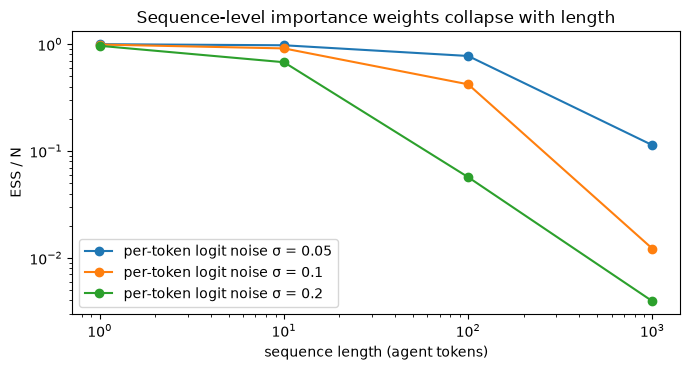

σ = 0.05: T=1: 99.8%, T=10: 97.5%, T=100: 77.4%, T=1000: 11.3%
σ = 0.1: T=1: 99.0%, T=10: 91.1%, T=100: 42.0%, T=1000: 1.2%
σ = 0.2: T=1: 96.3%, T=10: 67.6%, T=100: 5.7%, T=1000: 0.4%


In [6]:
rng = np.random.default_rng(0)
V = 50
lengths, sigmas = [1, 10, 100, 1000], [0.05, 0.1, 0.2]
ess = {}
for sigma in sigmas:
    for T in lengths:
        logw = []
        for _ in range(1000):
            l_mu = rng.normal(size=(T, V)); l_pi = l_mu + sigma * rng.normal(size=(T, V))
            p_mu = np.exp(l_mu - l_mu.max(1, keepdims=True)); p_mu /= p_mu.sum(1, keepdims=True)
            p_pi = np.exp(l_pi - l_pi.max(1, keepdims=True)); p_pi /= p_pi.sum(1, keepdims=True)
            y = (p_mu.cumsum(1) > rng.random((T, 1))).argmax(1)              # sample a sequence from mu
            logw.append(np.sum(np.log(p_pi[np.arange(T), y]) - np.log(p_mu[np.arange(T), y])))
        w = np.exp(np.array(logw) - np.max(logw))
        ess[(sigma, T)] = w.sum() ** 2 / (w ** 2).sum() / len(w)

fig, ax = plt.subplots(figsize=(7, 3.8))
for sigma in sigmas:
    ax.plot(lengths, [ess[(sigma, T)] for T in lengths], marker="o", label=f"per-token logit noise σ = {sigma}")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("sequence length (agent tokens)")
ax.set_ylabel("ESS / N"); ax.set_title("Sequence-level importance weights collapse with length"); ax.legend()
plt.tight_layout(); plt.show()
for sigma in sigmas:
    print(f"σ = {sigma}: " + ", ".join(f"T={T}: {ess[(sigma, T)]:.1%}" for T in lengths))

At 1,000 agent tokens (a short agent episode), even small per-token
differences leave only a few percent of the samples carrying the weight:
most of the batch is effectively ignored. That's why practical algorithms use
**per-token** ratios with clipping or truncation (PPO, GRPO, TIS), or
**length-normalized** sequence ratios (GSPO, i.e. the geometric mean). Both
trade a little bias for usable variance.

**The same math applies with no staleness at all.** The rollout engine (vLLM,
SGLang) and the trainer (FSDP / Megatron) compute slightly different
probabilities for the same tokens: different kernels, precision, batching. So
even "on-policy" RL is a little off-policy. Recent frameworks therefore apply
truncated importance sampling between the *sampler's* log-probs and the
*trainer's* log-probs. In `trl` that's `GRPOConfig(vllm_importance_sampling_correction=True)`,
with modes such as `"token_truncate"` and `"sequence_mask"` (the `trl` source
you saw in notebook 16 documents them).

## 3. The rest of the map

### Rewards when there's no verifier

Deep-research reports, customer-support conversations and open-ended coding
tasks often have no program that can grade them. Options, roughly in order
of robustness:

| approach | idea | main risk |
|---|---|---|
| decompose into checkable parts | final-state checks, unit tests, citations that must resolve, required fields | covers only part of quality |
| rubrics / checklists graded by an LLM | a task-specific list of criteria, each scored by a judge ("rubrics as rewards") | judge errors; the policy learns the judge's blind spots |
| pairwise / preference judges | compare two trajectories (like RLHF's reward model, notebook 7) | position and length bias; reward hacking of the judge |
| self-generated contrast (RLCD, notebooks 11 / 12.2) | preference labels from contrasting prompts | labels only as good as the contrast |

The same rule as Section 1 applies: **monitor a held-out signal** (human
spot-checks, a different judge, a small verified subset), not just the
optimized reward.

### Training instabilities specific to multi-turn RL

- **Echo trap / template collapse** (reported by RAGEN, 2025): the policy
  converges to a few repetitive reasoning templates. Rewards plateau, entropy and
  reward variance collapse, and then the run degrades. Their mitigations
  (StarPO-S): keep only high-variance groups (like DAPO's dynamic sampling,
  notebook 9), drop the KL term, and use asymmetric clipping ("clip-higher").
- **Entropy collapse.** As in notebook 9: monitor entropy over **agent tokens
  only**. Clip-higher, entropy bonuses and `trl`'s adaptive entropy control
  exist for this.
- **Zero-variance groups.** As tasks get solved, groups become all-success
  (notebooks 8, 13). Use curricula and pass-rate filtering.
- **Format drift across turns.** A malformed tool call in turn 3 derails the
  rest of the episode. Return parse errors as observations (notebook 14) and log
  `tools/failure_frequency` (notebook 16).

### Memory and context management

Long-horizon agents eventually exceed the context window: hundreds of tool
calls, each with a long observation. Common strategies: truncate old
observations, summarize history ("context compression"), give the agent
explicit **memory tools** (write and read notes, a scratch file), or train the
agent with RL to **manage its own memory**. Several 2025 works do the last one
(e.g., MEM1 learns to keep a compact internal state). In every case, training
must use the **same context policy** as deployment. Otherwise the agent learns
on histories it'll never see.

### Frameworks (as of this writing; check each project's docs, since they evolve quickly)

| framework | origin | notes |
|---|---|---|
| **`trl`** | Hugging Face | `GRPOTrainer` with `tools=`, `environment_factory=`, `rollout_func=`, vLLM integration (notebook 16) |
| **verl** (+ verl-agent) | ByteDance Seed (HybridFlow) | widely used for large-scale RLVR; multi-turn tool use; verl-agent hosts GiGPO |
| **OpenRLHF** | open-source community | Ray + vLLM; PPO / GRPO / REINFORCE++; agent support |
| **SkyRL** | UC Berkeley (NovaSky / Sky Computing) | long-horizon, real-environment agents (e.g. SWE tasks) |
| **rLLM** | Agentica / Berkeley | used for DeepSWE / DeepScaleR-style agents |
| **AReaL** | Ant Group & Tsinghua | fully asynchronous RL; decoupled PPO (Section 2) |
| **slime**, **ROLL** | Zhipu / THUDM; Alibaba | large-scale RL post-training systems |
| **ART**, **Agent Lightning** | OpenPipe; Microsoft | wrap existing agent code and train it with RL |
| **prime-rl** + **verifiers** | Prime Intellect | async RL, plus a library and hub of RL environments |

### Benchmarks people report for agents

SWE-bench Verified (fix real GitHub issues; hidden tests), Terminal-Bench
(shell tasks), WebArena / BrowseComp (web navigation and hard browsing), GAIA
(general assistant tasks with tools), τ-bench / τ²-bench (tool-calling
customer-service dialogues, checked by final database state), OSWorld
(computer use), BFCL (function-calling accuracy). Report **success rate and
cost per success** (tokens, tool calls, wall-clock), and **pass@k** when
sampling multiple attempts (notebook 8).

## 4. Wrap-up of Part III: a recipe for agentic RL

| step | what to do | why (notebook) |
|---|---|---|
| 1. **Start from a capable model** | instruct / tool-tuned; a short SFT "cold start" on a few hundred good trajectories if the format is shaky | RL sharpens what's already sampled (13, 16) |
| 2. **Build the environment first** | `reset` / `step`, strict parsing, errors returned as observations, budgets, a sandbox the agent can't escape | 14, 17 |
| 3. **Make the grader outcome-based and tamper-proof** | hidden tests, final-state checks, read-only graders; process rewards only if potential-based | 15, 17 |
| 4. **Mask observations** | loss and KL on agent tokens only; verify the mask | 13, 14 |
| 5. **Start with trajectory-level GRPO** | group of 8–16 per task, Dr. GRPO / DAPO aggregation | 9, 14 |
| 6. **Keep groups informative** | curriculum, pass-rate filtering, dynamic sampling | 13 |
| 7. **Add per-turn credit when horizons are long** | GiGPO-style grouping, a turn-level critic, $\gamma < 1$ | 15 |
| 8. **Scale with async, carefully** | bound staleness; truncated IS / decoupled PPO; correct sampler/trainer mismatch | 17 |
| 9. **Monitor more than the reward** | true success on held-out tasks, tool-call and failure rates, truncation, entropy, zero-variance groups, KL, and *read transcripts* | all |

### Open problems

- **Does RL teach new skills or only sharpen existing ones?** At the scale of
  these notebooks, it mostly sharpens (8, 12, 13). Long-horizon exploration,
  curricula and self-play are where genuinely new strategies might come from.
- **Credit assignment over hundreds of turns** with non-repeating states.
- **Rewards for open-ended work** (research, design, writing code that's
  maintainable, not just test-passing) without being hacked.
- **Safety under optimization**: agents act in the world, so reward hacking is
  no longer a curiosity in a log. It's the agent doing the wrong thing on
  someone's computer.

## 5. Key takeaways & FAQ

**The one-paragraph summary.** At scale, agentic RL is as much an
environment- and systems-engineering problem as an algorithmic one. If the
agent can modify what the grader reads, it'll learn to, and the reward curve
will look perfect while it does. Design graders the agent can't touch, and
always track true success separately. Long-tailed episodes force asynchronous
rollouts, which make training off-policy. Standard PPO-clip then wastes stale
data, sequence-level importance weights are hopeless at agent lengths, and the
practical answers are bounded staleness, per-token truncated importance
weights and decoupled trust regions.

**Q1. Is a KL penalty a defense against reward hacking?** A weak one. It slows
drift from the reference model, but in Section 1 the reference (SFT) model
*already* tampers in about 6% of episodes. The KL keeps the behavior possible. Only the
environment and the grader can make it unrewarding.

**Q2. How stale is too stale?** It depends on the learning rate and how fast
the policy moves. Many async systems cap staleness at a few versions and log
the importance-ratio statistics. If clipping fractions jump, the data is
too old for the trust region.

**Q3. Where should I go next?** Re-run notebook 16 with a stateful
`environment_factory` task (a small file system, a to-do list API), add a
hidden check that the agent can't see, and watch the reward-vs-true-success gap.
That one experiment exercises almost every idea in Part III.

**Exercises.**

1. Lower the SFT teacher's test-editing rate from 3% to 0.1% per decision. Does the hack
   still appear? How many more updates does it take? (RL needs the behavior
   to be *sampled*.)
2. In the staleness experiment, plot the fraction of clipped samples for PPO-clip
   versus $k$. At what staleness does PPO-clip lose most of its gradient?
3. Implement GSPO's length-normalized sequence ratio
   $\big(\prod_t \pi_\theta/\mu\big)^{1/T}$ in the ESS experiment. How does the ESS
   behave with length now?